# 08. Human-in-the-Loop (사람이 개입하는 워크플로)

> 고위험 작업은 LLM이 단독으로 결정하면 안 돼요. `interrupt_before` 로 그래프를 중단해 사람의 승인을 받는 가장 기본적인 HITL 패턴을 배웁니다.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `interrupt_before` 파라미터로 특정 노드 실행 전에 그래프를 중단시킬 수 있어요
2. `get_state()`로 중단된 그래프의 현재 상태와 대기 중인 도구 호출을 확인할 수 있어요
3. `graph.stream(None, config)`로 중단 지점에서 그래프를 재개할 수 있어요
4. `get_state_history()`로 모든 체크포인트를 조회하고 타임 트래블(Time Travel)을 구현할 수 있어요

## 사전 지식

- 이전 노트북: `07-Memory-Checkpointer.ipynb` - InMemorySaver, thread_id, 세션 관리
- `StateGraph`, `ToolNode`, `tools_condition` 기본 개념
- `MemorySaver` 체크포인터와 `config` 설정

## Human-in-the-Loop란?

에이전트는 때로 예상치 못한 방식으로 동작하거나, 민감한 작업(파일 삭제, 이메일 전송, 결제 처리 등)을 실행하기 전에 사람의 확인이 필요할 수 있어요.

### 왜 Human-in-the-Loop가 필요한가요?

자율 주행 자동차도 긴급 상황에서는 운전자가 직접 핸들을 잡을 수 있어야 하듯이, AI 에이전트도 **중요한 결정 앞에서 사람의 확인**을 받을 수 있어야 해요. 특히 결제 처리, 이메일 발송, 데이터 삭제처럼 되돌리기 어려운 작업에서는 사람의 최종 승인이 필수적이에요.

**Human-in-the-Loop(HITL)**는 에이전트 실행 중간에 사람이 개입할 수 있는 포인트를 만드는 패턴이에요.

> 🔑 **핵심 개념**: LangGraph에서 HITL은 두 가지 핵심 기능으로 구현해요:
> - **`interrupt_before`**: 특정 노드 실행 전에 그래프를 일시 중단
> - **`MemorySaver` 체크포인터**: 중단 상태를 저장하여 나중에 재개 가능

> ⚠️ **현재 권장 패턴 안내**: LangGraph 공식 문서는 프로덕션 HITL의 표준 패턴으로 `langgraph.types.interrupt()` 함수 + `Command(resume=...)`를 제시해요(디버깅용 정적 중단점과 구분). 이 노트북에서는 개념 이해를 돕기 위해 `interrupt_before`로 메커니즘(체크포인터 → 중단 → 재개 → Time Travel)을 먼저 익히고, `interrupt()` 함수 기반 패턴은 `06_Middleware/02-Human-In-The-Loop-V1.ipynb`에서 심화로 다뤄요.

### 핵심 구성 요소

| 구성 요소 | 역할 | 설명 |
|-----------|------|------|
| `interrupt_before` | 중단 지점 지정 | `compile(interrupt_before=["tools"])` |
| `MemorySaver` | 상태 저장 | 중단 시점의 상태를 메모리에 보관 |
| `get_state()` | 상태 조회 | 현재 스냅샷, 다음 노드, 대기 도구 확인 |
| `stream(None, config)` | 재개 | 입력 없이 중단 지점부터 이어서 실행 |
| `get_state_history()` | 기록 조회 | 모든 체크포인트를 역순으로 조회 |
| `checkpoint_id` | 타임 트래블 | 과거 특정 시점으로 되돌아가서 재실행 |

### 전체 워크플로 다이어그램

```mermaid
flowchart TD
    A([사용자 입력<br/>User Input]) --> B[chatbot 노드<br/>LLM 응답]
    B -->|도구 호출 필요| C{interrupt_before<br/>중단 지점}
    C -->|사람이 검토| D[사람의 판단<br/>Human Review]
    D -->|승인 - Resume| E[tools 노드<br/>도구 실행]
    D -->|거부 - 수정| F[상태 수정<br/>State Update]
    E --> B
    F --> B
    B -->|도구 호출 없음| G([최종 응답<br/>Final Answer])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef decision fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef human fill:#f8d7da,stroke:#dc3545,color:#721c24
    classDef output fill:#d4edda,stroke:#28a745,color:#155724

    class A input
    class B,E process
    class C decision
    class D,F human
    class G output
```

### 타임 트래블(Time Travel) 다이어그램

```mermaid
flowchart LR
    subgraph 체크포인트 기록
        CP0[checkpoint_0<br/>메시지 0개] --> CP1[checkpoint_1<br/>메시지 1개]
        CP1 --> CP2[checkpoint_2<br/>메시지 2개]
        CP2 --> CP3[checkpoint_3<br/>메시지 3개]
        CP3 --> CP4[checkpoint_4<br/>메시지 4개]
    end
    CP3 -->|checkpoint_id로 재실행| R[타임 트래블<br/>재실행]

    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085

    class CP0,CP1,CP2,CP3,CP4 storage
    class R process
```

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY 등을 불러와요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택사항)
# ---------------------------------------------------
# 추적을 원하면 아래 주석을 해제하고 실행하세요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-07-HITL"

## 1. 그래프 구성 — interrupt_before 설정

HITL 그래프는 이전 노트북의 도구 사용 챗봇과 동일한 구조에요. 핵심 차이는 `compile()` 시 `interrupt_before=["tools"]`를 추가하는 것이에요.

> 🎯 **강의 포인트**: `interrupt_before`는 `compile()` 메서드에 전달해요. 그래프 노드 추가 시가 아니라, 컴파일 단계에서 중단 지점을 결정한다는 점을 기억하세요.

> ⚠️ **자주 하는 실수**: `interrupt_before`를 사용할 때 반드시 `checkpointer`를 함께 설정해야 해요. 체크포인터가 없으면 중단 상태를 저장하지 못해서 재개가 불가능해요.

In [3]:
# ---------------------------------------------------
# 필요한 라이브러리 임포트
# ---------------------------------------------------
# 타입 힌트
from typing import Annotated, List, Dict
from typing_extensions import TypedDict

# LangChain V1 도구 및 모델
from langchain.chat_models import init_chat_model  # V1 통합 초기화 함수
from langchain.tools import tool                   # 도구 데코레이터
from langchain.messages import HumanMessage, AIMessage

# LangGraph 핵심 컴포넌트
from langgraph.checkpoint.memory import MemorySaver  # 메모리 체크포인터
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages      # 메시지 리듀서
from langgraph.prebuilt import ToolNode, tools_condition  # 도구 노드, 라우팅 조건

# 실행 설정
from langchain_core.runnables import RunnableConfig

In [4]:
# ---------------------------------------------------
# 1단계: 상태(State) 정의
# ---------------------------------------------------
# 메시지 목록을 관리하는 그래프 상태예요
class State(TypedDict):
    # add_messages 리듀서: 새 메시지를 기존 목록에 추가해요 (덮어쓰지 않아요)
    messages: Annotated[list, add_messages]

In [5]:
# ---------------------------------------------------
# TavilySearch: AI 에이전트용 웹 검색 도구
# ---------------------------------------------------
# langchain-tavily 패키지에서 실제 웹 검색 도구를 가져와요
# HITL에서는 "실제 도구를 실행하기 전에 사람이 확인"하는 게 핵심이에요
from langchain_tavily import TavilySearch

# TavilySearch 인스턴스 생성
search_tool = TavilySearch(max_results=3)

tools = [search_tool]
print(f"도구 목록: {[t.name for t in tools]}")

도구 목록: ['tavily_search']


In [6]:
# ---------------------------------------------------
# 3단계: 모델 초기화 및 도구 바인딩
# ---------------------------------------------------
# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
# 다른 모델 옵션:
#   - "anthropic:claude-3-5-haiku-20241022" (Anthropic)
#   - "google_genai:gemini-2.0-flash" (Google Gemini)
llm = init_chat_model("openai:gpt-4o-mini")

# 모델에 도구를 바인딩해요: LLM이 도구를 언제 호출할지 결정해요
llm_with_tools = llm.bind_tools(tools)

print("모델 초기화 완료:", llm.model_name)

모델 초기화 완료: gpt-4o-mini


In [7]:
# ---------------------------------------------------
# 4단계: 그래프 노드 및 엣지 구성
# ---------------------------------------------------

# 챗봇 노드: LLM을 호출하고 응답을 반환해요
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# 그래프 빌더 생성
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))  # 도구 실행 노드

# 엣지 구성
graph_builder.add_edge(START, "chatbot")             # 시작 → 챗봇
graph_builder.add_conditional_edges(                 # 챗봇 → (도구 or 종료)
    "chatbot",
    tools_condition,                                 # 도구 호출 있으면 tools, 없으면 END
)
graph_builder.add_edge("tools", "chatbot")           # 도구 → 챗봇 (결과를 LLM에 전달)

# 그래프 구조 구성 완료

In [8]:
# ---------------------------------------------------
# 5단계: interrupt_before와 함께 컴파일
# ---------------------------------------------------
# 핵심 설정:
#   checkpointer=memory: 중단 상태를 저장해요
#   interrupt_before=["tools"]: tools 노드 실행 전에 중단해요
memory = MemorySaver()  # 메모리 기반 체크포인터

graph = graph_builder.compile(
    checkpointer=memory,
    interrupt_before=["tools"],  # 이 노드 실행 전에 그래프를 일시 중단해요
)

# 그래프 컴파일 완료 (interrupt_before=['tools'] 설정됨)

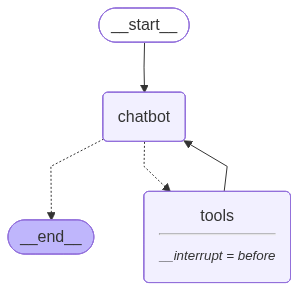

In [9]:
# 그래프 흐름: START → chatbot → tools → chatbot → ... → END
# chatbot 노드: LLM이 메시지를 처리하고 도구 호출 여부를 결정해요
# tools 노드: 도구를 실행하며, interrupt로 사람 승인을 요청할 수 있어요
# 조건부 엣지: tool_call 유무에 따라 tools 또는 END로 분기해요
# ---------------------------------------------------
# 그래프 구조 시각화
# ---------------------------------------------------
from IPython.display import Image, display

# 그래프를 Mermaid PNG로 시각화해요
display(Image(graph.get_graph().draw_mermaid_png()))

## 2. 그래프 실행 및 Interrupt 확인

이제 그래프를 실행해서 `interrupt_before`가 어떻게 동작하는지 직접 확인해볼게요.

도구 호출이 필요한 질문을 입력하면, `tools` 노드 실행 직전에 그래프가 일시 중단되는 걸 볼 수 있어요.

> 💡 **실무 팁**: `stream_mode="values"`는 각 단계마다 전체 상태를 반환해요. 반면 `stream_mode="updates"`는 변경된 부분만 반환해서 더 가볍게 사용할 수 있어요.

> 🤔 **자주 묻는 질문**: "`interrupt_before=['tools']`니까 모든 도구 호출 전에 멈추는 거죠?"
>
> 네, 맞아요. 이 설정에서는 LLM이 도구 호출(tool_call)을 결정해서 `tools` 노드로 라우팅되는 **모든 턴마다** `tools` 노드 실행 직전에 그래프가 일시 중단돼요. 다만 몇 가지 짚어둘 점이 있어요.
>
> - **노드 단위 중단**이지 도구 단위 중단이 아니에요. 한 번의 LLM 응답에 여러 `tool_call`이 들어 있어도 `tools` 노드는 한 번 실행되므로, 중단도 한 번이고 재개하면 그 안의 도구들이 한꺼번에 실행돼요. "도구별로 따로따로 승인"되는 게 아니에요.
> - LLM이 도구 호출을 안 하면 `tools_condition`이 바로 `END`로 보내므로 중단 자체가 일어나지 않아요.
> - "고위험 도구만 멈추기" 같은 **선택적 중단**은 `interrupt_before`로는 불가능해요. 위쪽 안내처럼 `langgraph.types.interrupt()` + `Command(resume=...)` 패턴(`06_Middleware/02-Human-In-The-Loop-V1.ipynb`)으로 가야 해요.

In [10]:
# ---------------------------------------------------
# 그래프 첫 번째 실행 (도구 호출 필요한 질문)
# ---------------------------------------------------
# 질문: 도구 호출이 필요한 내용으로 설정해요
question = "AI 관련 최신 동향을 알려주세요."

# 초기 입력 상태
initial_input = {"messages": [("user", question)]}

# 실행 설정: thread_id로 대화 세션을 구분해요
config = RunnableConfig(
    recursion_limit=10,          # 최대 노드 방문 횟수 (초과 시 RecursionError)
    configurable={"thread_id": "thread-1"},  # 이 대화의 고유 ID
)

print(f"질문: {question}")
# ============================================================
# 그래프 실행 시작...
print()

# stream_mode="values": 각 단계의 전체 상태를 반환해요
for event in graph.stream(initial_input, config, stream_mode="values"):
    # 현재 상태의 마지막 메시지만 출력해요
    if "messages" in event and event["messages"]:
        last_msg = event["messages"][-1]
        last_msg.pretty_print()

print()
# [실행 일시 중단 - interrupt_before 작동]

질문: AI 관련 최신 동향을 알려주세요.

================================ Human Message =================================

AI 관련 최신 동향을 알려주세요.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_TGkedt3EfbOzoTkq1tVSPimc)
 Call ID: call_TGkedt3EfbOzoTkq1tVSPimc
  Args:
    query: AI 최신 동향
    topic: news
    time_range: week



## 3. 현재 상태 확인 — get_state()

그래프가 중단되었을 때 `get_state()`로 현재 상태를 조회할 수 있어요.

> 🔑 **핵심 개념**: `snapshot.next`는 다음에 실행될 노드의 이름을 담고 있어요. 그래프가 정상 종료되면 `snapshot.next`는 빈 튜플 `()`이에요. `('tools',)`처럼 값이 있으면 아직 실행 중이라는 뜻이에요.

In [11]:
# ---------------------------------------------------
# 현재 그래프 상태 스냅샷 조회
# ---------------------------------------------------
# get_state(): 현재 체크포인트의 스냅샷을 반환해요
snapshot = graph.get_state(config)

# 다음에 실행될 노드 확인
# - ('tools',): tools 노드에서 대기 중 (interrupt 발생)
# - (): 그래프 실행 완료 (END 도달)
print("다음 실행 노드 (snapshot.next):", snapshot.next)
print()
print("현재 상태에 저장된 메시지 수:", len(snapshot.values["messages"]))

다음 실행 노드 (snapshot.next): ('tools',)

현재 상태에 저장된 메시지 수: 2


In [12]:
# ---------------------------------------------------
# 대기 중인 도구 호출 정보 확인
# ---------------------------------------------------
# snapshot.values["messages"][-1]: 마지막 메시지 (AIMessage with tool_calls)
last_message = snapshot.values["messages"][-1]

print("마지막 메시지 타입:", last_message.type)
print()

# tool_calls: 실행을 기다리고 있는 도구 호출 목록
if hasattr(last_message, "tool_calls") and last_message.tool_calls:
    # 대기 중인 도구 호출:
    for i, tc in enumerate(last_message.tool_calls):
        print(f"  [{i}] 도구 이름: {tc['name']}")
        print(f"       인자: {tc['args']}")
        print(f"       ID: {tc['id']}")
else:
    # 대기 중인 도구 호출 없음
    pass

마지막 메시지 타입: ai

  [0] 도구 이름: tavily_search
       인자: {'query': 'AI 최신 동향', 'topic': 'news', 'time_range': 'week'}
       ID: call_TGkedt3EfbOzoTkq1tVSPimc


## 4. 그래프 재개 — Resume with None

사람이 검토 후 실행을 승인하면, 그래프를 재개할 수 있어요.

> 🎯 **강의 포인트**: 중단 지점에서 재개하려면 `graph.stream(None, config)`처럼 입력값에 `None`을 전달해요. `None`은 "새로운 입력 없이 중단된 지점부터 계속 실행하라"는 신호예요.

> 💡 **실무 팁**: 실제 프로덕션에서는 이 지점에서 Slack 알림이나 웹 UI를 통해 사람에게 승인 요청을 보내요.

### `None` 입력 vs 새 입력의 차이

| 입력 | 동작 | 사용 시점 |
|------|------|----------|
| `graph.stream(None, config)` | 중단 지점에서 **그대로 재개** | 승인 후 원래 도구를 실행할 때 |
| `graph.stream({"messages": [...]}, config)` | 새 메시지를 추가하고 재실행 | 사용자가 질문을 수정할 때 | 사람이 승인하면 `stream(None, config)`를 호출하고, 거부하면 상태를 수정하거나 다른 처리를 진행해요.

In [13]:
# ---------------------------------------------------
# 그래프 재개 (Resume)
# ---------------------------------------------------
# 입력값으로 None을 전달하면:
#   - 새로운 입력 없이 현재 체크포인트부터 실행을 이어가요
#   - tools 노드부터 실행이 재개돼요
# ============================================================
# 그래프 재개 (None 입력으로 중단 지점부터 계속 실행)
# ============================================================

# None: 현재 상태에 아무것도 추가하지 않고 이어서 실행해요
for event in graph.stream(None, config, stream_mode="values"):
    if "messages" in event and event["messages"]:
        last_msg = event["messages"][-1]
        last_msg.pretty_print()

print()
# [실행 완료]

================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_TGkedt3EfbOzoTkq1tVSPimc)
 Call ID: call_TGkedt3EfbOzoTkq1tVSPimc
  Args:
    query: AI 최신 동향
    topic: news
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{'error': ValueError('Error 401: Unauthorized: missing or invalid API key.')}
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_FYkAxm6ZbQkWIbqF5OnXyWw5)
 Call ID: call_FYkAxm6ZbQkWIbqF5OnXyWw5
  Args:
    query: AI 최신 동향
    topic: news
    time_range: week



In [14]:
# ---------------------------------------------------
# 재개 후 상태 확인
# ---------------------------------------------------
# 정상 종료되면 snapshot.next가 빈 튜플 () 이어야 해요
final_snapshot = graph.get_state(config)

print("실행 완료 후 snapshot.next:", final_snapshot.next)
print("최종 메시지 수:", len(final_snapshot.values["messages"]))

실행 완료 후 snapshot.next: ('tools',)
최종 메시지 수: 4


## 5. 상태 기록 조회 — get_state_history()

LangGraph는 그래프 실행의 모든 단계에서 체크포인트를 저장해요. `get_state_history()`로 전체 실행 기록을 조회할 수 있어요.

> 🔑 **핵심 개념**: 상태 기록은 **역순**(최신 → 오래된 순)으로 반환돼요. 각 체크포인트는 고유한 `checkpoint_id`를 가져요. 이 ID를 사용하면 그 시점으로 되돌아가서 재실행할 수 있어요 — 이것이 **타임 트래블(Time Travel)** 이에요.

> 💡 **실무 팁**: 상태 기록을 활용하면 에이전트가 어떤 경로로 실행되었는지 디버깅하거나, 잘못된 시점을 찾아서 다시 실행할 수 있어요.

In [15]:
# ---------------------------------------------------
# 전체 상태 기록 조회
# ---------------------------------------------------
# get_state_history(): 현재까지의 모든 체크포인트를 역순으로 반환해요
# 전체 상태 기록 (최신 → 오래된 순):
# ============================================================

for i, state in enumerate(graph.get_state_history(config)):
    msg_count = len(state.values["messages"])
    next_node = state.next
    checkpoint_id = state.config["configurable"].get("checkpoint_id", "N/A")
    
    print(f"[체크포인트 {i}]")
    print(f"  메시지 수: {msg_count}")
    print(f"  다음 노드: {next_node}")
    print(f"  checkpoint_id: {checkpoint_id[:20]}...")  # 일부만 출력
    # ----------------------------------------

[체크포인트 0]
  메시지 수: 4
  다음 노드: ('tools',)
  checkpoint_id: 1f150234-509e-6ad8-8...
[체크포인트 1]
  메시지 수: 3
  다음 노드: ('chatbot',)
  checkpoint_id: 1f150234-45a8-6886-8...
[체크포인트 2]
  메시지 수: 2
  다음 노드: ('tools',)
  checkpoint_id: 1f150234-3fc9-65c8-8...
[체크포인트 3]
  메시지 수: 1
  다음 노드: ('chatbot',)
  checkpoint_id: 1f150234-3186-60c4-8...
[체크포인트 4]
  메시지 수: 0
  다음 노드: ('__start__',)
  checkpoint_id: 1f150234-3184-6daa-b...


In [16]:
# ---------------------------------------------------
# 특정 체크포인트 선택 (타임 트래블용)
# ---------------------------------------------------
# 메시지가 3개인 체크포인트를 찾아볼게요
# (사용자 메시지 + AI 도구 호출 메시지 + 도구 결과 메시지)
to_replay = None

for state in graph.get_state_history(config):
    msg_count = len(state.values["messages"])
    # 메시지 수가 3개인 체크포인트 선택
    if msg_count == 3:
        to_replay = state
        break

if to_replay:
    # 선택된 체크포인트:
    print(f"  메시지 수: {len(to_replay.values['messages'])}")
    print(f"  다음 노드: {to_replay.next}")
    print(f"  config: {to_replay.config}")
else:
    # 해당 조건의 체크포인트를 찾지 못했어요
    pass

  메시지 수: 3
  다음 노드: ('chatbot',)
  config: {'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f150234-45a8-6886-8002-312389543831'}}


## 6. 타임 트래블 — checkpoint_id로 과거 시점 재실행

선택한 체크포인트의 `config`를 사용하면, 그 시점부터 그래프를 다시 실행할 수 있어요.

> 🎯 **강의 포인트**: 타임 트래블은 `to_replay.config`를 `stream()` 또는 `invoke()`에 그대로 전달하면 돼요. 이 config 안에 `checkpoint_id`가 포함되어 있어서 LangGraph가 그 시점의 상태를 복원해요.

> ⚠️ **자주 하는 실수**: 타임 트래블 시에도 입력값은 `None`을 전달해야 해요. 새로운 입력을 주면 해당 체크포인트 이후 새로운 실행 경로가 생성돼요.

> 💡 **실무 팁**: 타임 트래블의 실무 활용 예시: (1) LLM이 잘못된 도구를 선택한 경우, 도구 호출 직전으로 돌아가 파라미터를 수정 후 재실행 (2) A/B 테스트처럼 같은 시점에서 다른 도구를 호출해 결과를 비교 (3) 에이전트 디버깅 시 특정 시점의 상태를 재현하여 원인 분석.

In [17]:
# ---------------------------------------------------
# 타임 트래블: 특정 체크포인트부터 재실행
# ---------------------------------------------------
if to_replay:
    print(f"체크포인트에서 재실행 시작 (메시지 {len(to_replay.values['messages'])}개 상태)")
    # ============================================================
    
    # to_replay.config: checkpoint_id가 포함된 설정이에요
    # None: 새로운 입력 없이 그 시점부터 이어서 실행해요
    for event in graph.stream(None, to_replay.config, stream_mode="values"):
        if "messages" in event and event["messages"]:
            last_msg = event["messages"][-1]
            last_msg.pretty_print()
    
    print()
    # [타임 트래블 재실행 완료]
else:
    # 재실행할 체크포인트가 없어요
    pass

체크포인트에서 재실행 시작 (메시지 3개 상태)
================================= Tool Message =================================
Name: tavily_search

{'error': ValueError('Error 401: Unauthorized: missing or invalid API key.')}
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_85dxqDBPK49UU5sygQ7T4W70)
 Call ID: call_85dxqDBPK49UU5sygQ7T4W70
  Args:
    query: AI 최신 동향
    topic: news
    time_range: week



## 7. 실습 — 나만의 HITL 워크플로 구성

아래 TODO 블록을 완성해서 직접 Human-in-the-Loop 워크플로를 실험해보세요!

In [18]:
# ============================================================
# 구현 예시: 새로운 thread_id로 HITL 워크플로 처음부터 실행
# ============================================================
new_config = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": "thread-2"},
)

new_question = "LangGraph의 Human-in-the-Loop 최신 사용 패턴을 검색해서 알려주세요."
new_input = {"messages": [("user", new_question)]}

print(f"질문: {new_question}")
print("\n[1단계] tools 노드 직전까지 실행")
for event in graph.stream(new_input, new_config, stream_mode="values"):
    if "messages" in event and event["messages"]:
        event["messages"][-1].pretty_print()

new_snapshot = graph.get_state(new_config)
print(f"\n중단 후 next: {new_snapshot.next}")

if new_snapshot.next == ("tools",):
    print("\n[2단계] 도구 실행 승인 후 재개")
    for event in graph.stream(None, new_config, stream_mode="values"):
        if "messages" in event and event["messages"]:
            event["messages"][-1].pretty_print()
else:
    print("도구 호출이 없어 재개할 중단 지점이 없습니다.")


질문: LangGraph의 Human-in-the-Loop 최신 사용 패턴을 검색해서 알려주세요.

[1단계] tools 노드 직전까지 실행
================================ Human Message =================================

LangGraph의 Human-in-the-Loop 최신 사용 패턴을 검색해서 알려주세요.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_VynjzOWkgM8Uvaz3lVM5tHuJ)
 Call ID: call_VynjzOWkgM8Uvaz3lVM5tHuJ
  Args:
    query: LangGraph Human-in-the-Loop 사용 패턴
    topic: general
    time_range: month
    search_depth: advanced

중단 후 next: ('tools',)

[2단계] 도구 실행 승인 후 재개
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_VynjzOWkgM8Uvaz3lVM5tHuJ)
 Call ID: call_VynjzOWkgM8Uvaz3lVM5tHuJ
  Args:
    query: LangGraph Human-in-the-Loop 사용 패턴
    topic: general
    time_range: month
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{'error': ValueError('Error 401: Unaut

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

| 기능 | 코드 | 설명 |
|------|------|------|
| **중단 지점 설정** | `compile(interrupt_before=["tools"])` | 지정 노드 실행 전 그래프 일시 중단 |
| **상태 조회** | `graph.get_state(config)` | 현재 스냅샷, `next` 노드, 대기 도구 확인 |
| **재개** | `graph.stream(None, config)` | 입력 없이 중단 지점부터 이어서 실행 |
| **기록 조회** | `graph.get_state_history(config)` | 모든 체크포인트를 역순으로 조회 |
| **타임 트래블** | `graph.stream(None, to_replay.config)` | 특정 `checkpoint_id`로 과거 시점 재실행 |

- **`interrupt_before`**: `compile()` 시 설정하며, 반드시 `checkpointer`와 함께 사용해야 해요
- **`snapshot.next`**: `('tools',)`이면 중단 중, `()`이면 실행 완료를 의미해요
- **`snapshot.values["messages"][-1].tool_calls`**: 대기 중인 도구 호출 정보를 담고 있어요
- **타임 트래블**: `checkpoint_id`를 활용해 과거 상태로 되돌아가서 다른 방향으로 재실행할 수 있어요

## 다음 노트북 예고

다음 `09-State-Management.ipynb`에서는 **Custom State, State History, 롤백**을 배워요. 단순한 메시지 목록을 넘어서 복잡한 상태를 정의하고, `update_state()`로 상태를 직접 수정하는 방법과 체크포인트를 활용한 롤백 전략을 다뤄요.